# Load flow 

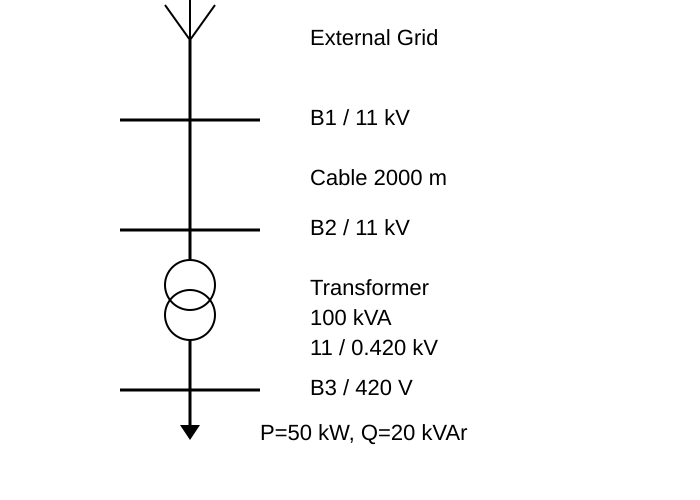

In [1]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="500" viewBox="0 0 700 500">

  <!-- Bus B1 -->
  <line x1="120" y1="120" x2="260" y2="120"
        stroke="black" stroke-width="3"/>

  <!-- External Grid symbol -->
  <line x1="190" y1="120" x2="190" y2="40"
        stroke="black" stroke-width="3"/>

  <line x1="190" y1="40" x2="165" y2="5"
        stroke="black" stroke-width="2"/>
  <line x1="190" y1="40" x2="190" y2="0"
        stroke="black" stroke-width="2"/>
  <line x1="190" y1="40" x2="215" y2="5"
        stroke="black" stroke-width="2"/>

  <!-- Cable -->
  <line x1="190" y1="120" x2="190" y2="230"
        stroke="black" stroke-width="3"/>

  <!-- Bus B2 -->
  <line x1="120" y1="230" x2="260" y2="230"
        stroke="black" stroke-width="3"/>

  <!-- Transformer -->
  <line x1="190" y1="230" x2="190" y2="260"
        stroke="black" stroke-width="3"/>

  <circle cx="190" cy="285" r="25"
          fill="none" stroke="black" stroke-width="2"/>
  <circle cx="190" cy="315" r="25"
          fill="none" stroke="black" stroke-width="2"/>

  <line x1="190" y1="340" x2="190" y2="390"
        stroke="black" stroke-width="3"/>

  <!-- Bus B3 -->
  <line x1="120" y1="390" x2="260" y2="390"
        stroke="black" stroke-width="3"/>

  <!-- Load -->
  <line x1="190" y1="390" x2="190" y2="425"
        stroke="black" stroke-width="3"/>

  <polygon points="180,425 200,425 190,440"
           fill="black"/>

  <!-- Labels -->
  <text x="310" y="45" font-family="Arial" font-size="22">
    External Grid
  </text>

  <text x="310" y="125" font-family="Arial" font-size="22">
    B1 / 11 kV
  </text>

  <text x="310" y="185" font-family="Arial" font-size="22">
    Cable 2000 m
  </text>

  <text x="310" y="235" font-family="Arial" font-size="22">
    B2 / 11 kV
  </text>

  <text x="310" y="295" font-family="Arial" font-size="22">
    Transformer
  </text>

  <text x="310" y="325" font-family="Arial" font-size="22">
    100 kVA
  </text>

  <text x="310" y="355" font-family="Arial" font-size="22">
    11 / 0.420 kV
  </text>

  <text x="310" y="395" font-family="Arial" font-size="22">
    B3 / 420 V
  </text>

  <text x="260" y="440" font-family="Arial" font-size="22">
    P=50 kW, Q=20 kVAr
  </text>

</svg>
"""

glue("last_flyt", SVG(svg), display=True)

In [2]:
import pandapower as pp

# Opprett nett
net = pp.create_empty_network()

# ------------------------------------------------------------------
# Busser
# ------------------------------------------------------------------
b1 = pp.create_bus(net, vn_kv=11.0, name="B1")
b2 = pp.create_bus(net, vn_kv=11.0, name="B2")
b3 = pp.create_bus(net, vn_kv=0.42, name="B3")

# ------------------------------------------------------------------
# Eksternnett
# ------------------------------------------------------------------
pp.create_ext_grid(
    net,
    bus=b1,
    vm_pu=1.0,
    name="External Grid"
)

# ------------------------------------------------------------------
# Kabel 2000 m
# Eksempeldata for 11 kV-kabel
# ------------------------------------------------------------------
pp.create_line_from_parameters(
    net,
    from_bus=b1,
    to_bus=b2,
    length_km=2.0,
    r_ohm_per_km=0.443,
    x_ohm_per_km=0.080,
    c_nf_per_km=210,
    max_i_ka=0.2,
    name="Cable 2000 m"
)

# ------------------------------------------------------------------
# Transformator 100 kVA, 11/0.42 kV
# ------------------------------------------------------------------
pp.create_transformer_from_parameters(
    net,
    hv_bus=b2,
    lv_bus=b3,
    sn_mva=0.1,
    vn_hv_kv=11.0,
    vn_lv_kv=0.42,
    vk_percent=4.0,
    vkr_percent=1.0,
    pfe_kw=0.3,
    i0_percent=0.5,
    shift_degree=0,
    name="100 kVA Transformer"
)

# ------------------------------------------------------------------
# Last
# ------------------------------------------------------------------
pp.create_load(
    net,
    bus=b3,
    p_mw=0.050,
    q_mvar=0.020,
    name="Load"
)

# ------------------------------------------------------------------
# Lastflyt
# ------------------------------------------------------------------
pp.runpp(net)

# ------------------------------------------------------------------
# Resultater
# ------------------------------------------------------------------
print("\nBusspenninger")
print(net.res_bus[["vm_pu", "va_degree"]])

print("\nLinjebelastning")
print(net.res_line[["loading_percent", "pl_mw", "ql_mvar"]])

print("\nTransformator")
print(net.res_trafo[["loading_percent", "pl_mw", "ql_mvar"]])

print("\nEksternnett")
print(net.res_ext_grid)


Busspenninger
      vm_pu  va_degree
0  1.000000   0.000000
1  0.999611   0.001865
2  0.986443  -1.009404

Linjebelastning
   loading_percent    pl_mw   ql_mvar
0         1.443866  0.00002 -0.015956

Transformator
   loading_percent     pl_mw   ql_mvar
0        55.018687  0.000596  0.001558

Eksternnett
       p_mw    q_mvar
0  0.050616  0.005602


In [3]:
import pandapower as pp

net = pp.create_empty_network()

# Busser
b1 = pp.create_bus(net, vn_kv=11.0, name="B1")
b2 = pp.create_bus(net, vn_kv=11.0, name="B2")
b3 = pp.create_bus(net, vn_kv=0.42, name="B3")

# Eksternnett
pp.create_ext_grid(net, b1, vm_pu=1.0)

# Kabel 2000 m
pp.create_line_from_parameters(
    net,
    from_bus=b1,
    to_bus=b2,
    length_km=2.0,
    r_ohm_per_km=0.0,
    x_ohm_per_km=0.1,
    c_nf_per_km=0.0,
    max_i_ka=1.0
)

# Trafo 100 kVA 11/0.42 kV
pp.create_transformer_from_parameters(
    net,
    hv_bus=b2,
    lv_bus=b3,
    sn_mva=0.1,
    vn_hv_kv=11.0,
    vn_lv_kv=0.42,
    vk_percent=4.0,
    vkr_percent=1.0,
    pfe_kw=0.3,
    i0_percent=0.5,
    shift_degree=0
)

# Last
pp.create_load(
    net,
    bus=b3,
    p_mw=0.05,
    q_mvar=0.02
)

# Lastflyt
pp.runpp(net)

print(net.res_bus[["vm_pu", "va_degree"]])
print(net.res_line[["loading_percent"]])
print(net.res_trafo[["loading_percent"]])

      vm_pu  va_degree
0  1.000000   0.000000
1  0.999964  -0.004792
2  0.986801  -1.015339
   loading_percent
0          0.28867
   loading_percent
0        54.999046


In [4]:
import pandapower as pp

net = pp.create_empty_network()

# Busser
b1 = pp.create_bus(net, vn_kv=11.0, name="B1")
b2 = pp.create_bus(net, vn_kv=11.0, name="B2")
b3 = pp.create_bus(net, vn_kv=0.42, name="B3")

# Eksternnett
pp.create_ext_grid(net, bus=b1, vm_pu=1.0)

# Kabel 2000 m
pp.create_line_from_parameters(
    net,
    from_bus=b1,
    to_bus=b2,
    length_km=2.0,
    r_ohm_per_km=0.0,
    x_ohm_per_km=0.1,
    c_nf_per_km=0.0,
    max_i_ka=1.0,
    name="Cable 2000 m"
)

# Trafo 100 kVA, 11/0.42 kV
pp.create_transformer_from_parameters(
    net,
    hv_bus=b2,
    lv_bus=b3,
    sn_mva=0.1,
    vn_hv_kv=11.0,
    vn_lv_kv=0.42,
    vk_percent=3.0,
    vkr_percent=0.0,
    pfe_kw=0.0,
    i0_percent=0.0,
    shift_degree=0,
    name="Transformer"
)

# Last
pp.create_load(
    net,
    bus=b3,
    p_mw=0.05,
    q_mvar=0.02,
    name="Load"
)

# Lastflyt
pp.runpp(net)

print("\nBusspenninger")
print(net.res_bus[["vm_pu", "va_degree"]])

print("\nLinje")
print(net.res_line)

print("\nTrafo")
print(net.res_trafo)

print("\nEksternnett")
print(net.res_ext_grid)


Busspenninger
      vm_pu  va_degree
0  1.000000   0.000000
1  0.999965  -0.004735
2  0.993814  -0.869584

Linje
   p_from_mw  q_from_mvar  p_to_mw  q_to_mvar         pl_mw   ql_mvar  \
0       0.05     0.020886    -0.05  -0.020881  6.938894e-18  0.000005   

   i_from_ka   i_to_ka      i_ka  vm_from_pu  va_from_degree  vm_to_pu  \
0   0.002844  0.002844  0.002844         1.0             0.0  0.999965   

   va_to_degree  loading_percent  
0     -0.004735         0.284407  

Trafo
   p_hv_mw  q_hv_mvar  p_lv_mw  q_lv_mvar  pl_mw   ql_mvar   i_hv_ka  \
0     0.05   0.020881    -0.05      -0.02    0.0  0.000881  0.002844   

    i_lv_ka  vm_hv_pu  va_hv_degree  vm_lv_pu  va_lv_degree  loading_percent  
0  0.074488  0.999965     -0.004735  0.993814     -0.869584        54.186834  

Eksternnett
   p_mw    q_mvar
0  0.05  0.020886
